# BioNeMo Inference Runtime on Colab


This has been tested on Colab pro with A100 GPUs.

In [2]:
!python --version
!python -m pip install --upgrade pip
!python -m pip install bionemo-ir py3Dmol

Python 3.12.12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter co

In [3]:
!pip install --force-reinstall --no-cache-dir --no-deps cuda-bindings==13.4.1
!git clone https://github.com/NVIDIA-BioNeMo/BioNeMo-Inference-Runtime.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 145.3 MB/s  0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.4.1
    Uninstalling cuda-bindings-13.4.1:
      Successfully uninstalled cuda-bindings-13.4.1
Cloning into 'BioNeMo-Inference-Runtime'...
remote: Enumerating objects: 972, done.
remote: Counting objects: 100% (648/648), done.
remote: Compressing objects: 100% (599/599), done.
remote: Total 972 (delta 125), reused 238 (delta 45), pack-reused 324 (from 1)
Receiving objects: 100% (972/972), 2.52 MiB | 13.57 MiB/s, done.
Resolving deltas: 100% (160/160), done.
Filtering content: 100% (104/104), 84.39 MiB | 30.19 MiB/s, done.
/content/BioNeMo-Inference-Runtime


In [3]:
!cp -r BioNeMo-Inference-Runtime/examples .

In [4]:
import bionemo_ir
from huggingface_hub import login


login()  # paste your HF token when prompted
print(bionemo_ir.__version__)

In [6]:
## Run example from the repository
!python examples/quickstart/boltz2.py

2026-09-11 03:49:18,089 - numexpr.utils - INFO - NumExpr defaulting to 12 threads.
2026-09-11 03:49:18,430 - bionemo_ir.hubs.metadata - INFO - Downloading ccd_path from boltz-community/boltz-1/ccd.pkl
ccd.pkl: 100% 346M/346M [00:01<00:00, 275MB/s]
2026-09-11 03:49:19,884 - bionemo_ir.hubs.metadata - INFO - Downloading mol_dir from boltz-community/boltz-2/mols.tar
mols.tar: 100% 1.86G/1.86G [00:08<00:00, 207MB/s]
2026-09-11 03:49:30,482 - bionemo_ir.hubs.metadata - INFO - Extracting /root/.cache/bionemo_ir/boltz-2/models--boltz-community--boltz-2/snapshots/6fdef46d763fee7fbb83ca5501ccceff43b85607/mols.tar to /root/.cache/bionemo_ir/boltz-2
2026-09-11 03:49:46,979 - bionemo_ir.dsl_kernels.triton_cache - INFO - Triton disk cache is cold (/tmp/root/bioir_kernel_cache/triton) — kernel compilations will use subprocess to avoid in-process degradation
2026-09-11 03:50:49,892 - bionemo_ir.hubs.local - INFO - Not found local checkpoint for boltz-2, using default repo id BOLTZ2_CKPT
boltz2_conf.c

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt
import py3Dmol

SCORES_PATH = "./output/serial/T1031_scores.json"
STRUCTURE_PATH = "./output/serial/T1031.cif"

Residues: 95 | pTM: 0.5078 | ipTM: 0.0 | mean pLDDT: 0.651


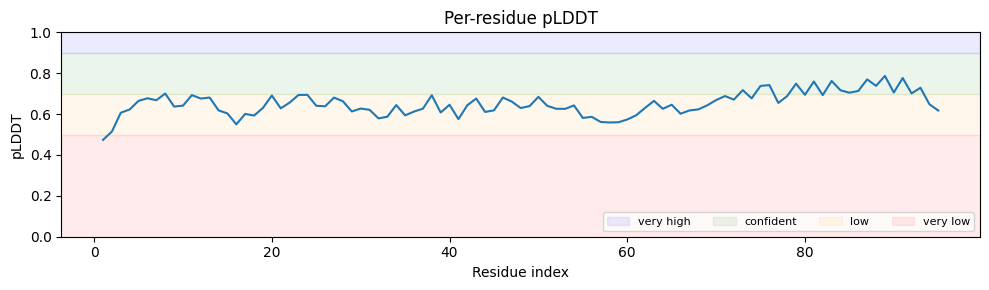

In [9]:
with open(SCORES_PATH) as f:
    scores = json.load(f)

with open(STRUCTURE_PATH) as f:
    structure_data = f.read()

plddt = scores["plddt"]
pae = np.array(scores["pae"])
max_pae = scores.get("max_pae", pae.max())
ptm = scores.get("ptm")
iptm = scores.get("iptm")

print(f"Residues: {len(plddt)} | pTM: {ptm} | ipTM: {iptm} | mean pLDDT: {np.mean(plddt):.3f}")

plt.figure(figsize=(10, 3))
plt.plot(range(1, len(plddt) + 1), plddt, color="#1f77b4")
plt.axhspan(0.9, 1.0, color="blue", alpha=0.08, label="very high")
plt.axhspan(0.7, 0.9, color="green", alpha=0.08, label="confident")
plt.axhspan(0.5, 0.7, color="orange", alpha=0.08, label="low")
plt.axhspan(0.0, 0.5, color="red", alpha=0.08, label="very low")
plt.ylim(0, 1)
plt.xlabel("Residue index")
plt.ylabel("pLDDT")
plt.title("Per-residue pLDDT")
plt.legend(loc="lower right", fontsize=8, ncol=4)
plt.tight_layout()
plt.show()



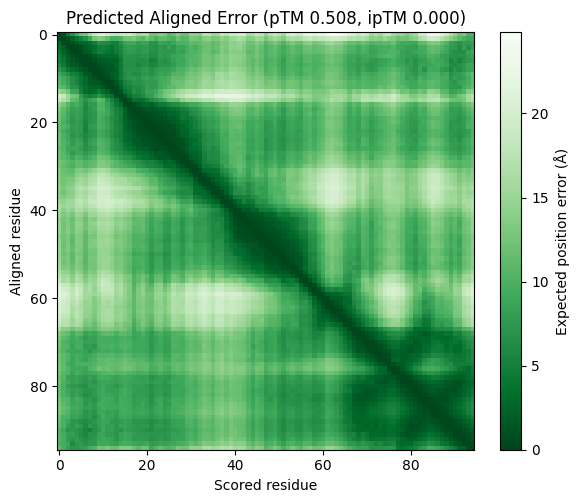

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pae, cmap="Greens_r", vmin=0, vmax=max_pae)
ax.set_xlabel("Scored residue")
ax.set_ylabel("Aligned residue")
ax.set_title(f"Predicted Aligned Error (pTM {ptm:.3f}, ipTM {iptm:.3f})")
fig.colorbar(im, label="Expected position error (Å)")
plt.tight_layout()
plt.show()

In [11]:
fmt = "cif" if STRUCTURE_PATH.lower().endswith(".cif") else "pdb"

view = py3Dmol.view(width=800, height=600)
view.addModel(structure_data, fmt)
view.setStyle({
    "cartoon": {
        "colorscheme": {"prop": "b", "gradient": "roygb", "min": 0.5, "max": 0.9}
    }
})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [12]:
# RUNNING FOLDING MODEL
# you need to fill out the form here to get the checkpoints: https://huggingface.co/OpenFold/OpenFold3

In [13]:
!python examples/folding/run_demo.py \
    --model-source openfold3 \
    --input examples/data/samples/monomers/T1031.json \
    --output-dir output \
    --sampling-steps 50

2026-09-11 03:52:07,655 - numexpr.utils - INFO - NumExpr defaulting to 12 threads.
2026-09-11 03:52:20,977 - bionemo_ir.hubs.local - INFO - Not found local checkpoint for openfold3, using default repo id OPENFOLD3_CKPT
checkpoints/of3-p2-155k.pt: 100% 2.29G/2.29G [00:08<00:00, 262MB/s]
Wrote 1 prediction(s) to output


In [20]:
import json, time, gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import py3Dmol
import torch

from bionemo_ir.data.schemas import InputRequest, MSARecord, Polymer
from bionemo_ir.pipeline.processor.engine_proc import EngineProcessorConfig, build_processor
from bionemo_ir.pipeline.stages.configs import FeatureGeneratorStageConfig, WriterStageConfig

SEQUENCE = "ACKIENIKYKGKEVESKLGSQLIDIFNDLDRAKEEYDKLSSPEFIAKFGDWINDEVERNVNEDGEPLLIQDVRQDSSKHYFFILKNGERFDLLTR"

def run_bioir_model(model_source, sequence=SEQUENCE, sampling_steps=50, output_dir=None):
    """Run one BioIR model_source on a single sequence, timed."""
    request = InputRequest(
        input_id="target",
        polymers=[Polymer(
            chain_id=["A1"],
            sequence=sequence,
            msas=[MSARecord(content=f">target\n{sequence}\n")],
        )],
    )
    rows = [{"record": request, "__record_id": request["input_id"]}]

    runtime_args = {"num_sampling_steps": sampling_steps} if model_source in {"boltz-1", "boltz-2", "openfold3"} else {}

    config = EngineProcessorConfig(
        model_source=model_source,
        runtime_args=runtime_args,
        feature_generator_stage=FeatureGeneratorStageConfig(init_context={"random_seed": 42}),
        writer_stage=WriterStageConfig(output_path=output_dir, format="cif"),
        engine_kwargs={"profile_inference": True},
    )
    row = build_processor(config)(rows)[0]
    scores = json.loads(row["scores"])
    return row, scores

def plot_plddt(scores, title=""):
    plddt = scores["plddt"]
    plt.figure(figsize=(9, 2.5))
    plt.plot(range(1, len(plddt) + 1), plddt, color="#1f77b4")
    plt.ylim(0, 1)
    plt.xlabel("Residue index"); plt.ylabel("pLDDT")
    plt.title(f"Per-residue pLDDT {title}")
    plt.tight_layout(); plt.show()

def plot_pae(scores, title=""):
    pae = np.array(scores["pae"])
    fig, ax = plt.subplots(figsize=(5, 4.5))
    im = ax.imshow(pae, cmap="Greens_r", vmin=0, vmax=scores.get("max_pae", pae.max()))
    ax.set_title(f"PAE {title} (pTM {scores['ptm']:.2f})")
    fig.colorbar(im, label="Å")
    plt.tight_layout(); plt.show()

def show_structure(cif_text, plddt_range=(0.5, 0.9)):
    view = py3Dmol.view(width=800, height=600)
    view.addModel(cif_text, "cif")
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb",
                                                "min": plddt_range[0], "max": plddt_range[1]}}})
    view.zoomTo()
    view.show()

def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()

pTM: 0.508 | ipTM: 0.000 | mean pLDDT: 0.651


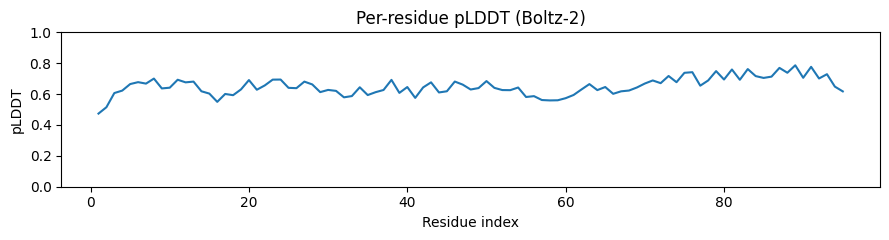

In [21]:
row, scores = run_bioir_model("boltz-2", output_dir="output/demo")
print(f"pTM: {scores['ptm']:.3f} | ipTM: {scores['iptm']:.3f} | mean pLDDT: {np.mean(scores['plddt']):.3f}")

plot_plddt(scores, "(Boltz-2)")

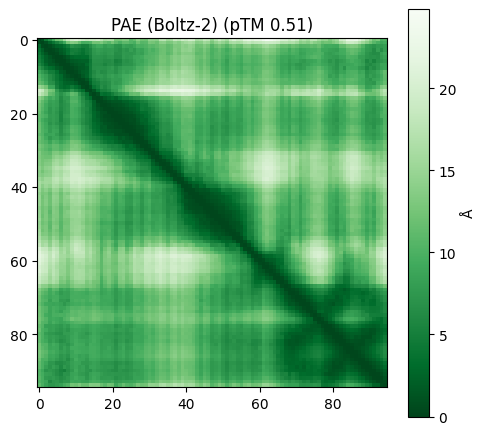

In [22]:
plot_pae(scores, "(Boltz-2)")

In [23]:
show_structure(row["output_raw"])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [24]:
free_gpu()

In [25]:
BIOIR_MODELS = ["boltz-1", "boltz-2", "openfold3", "openfold2_ptm_1"]

def normalize_plddt(plddt_list):
    """Some models report pLDDT on 0-1, others on 0-100. Normalize to 0-1."""
    arr = np.array(plddt_list, dtype=float)
    return (arr / 100.0) if arr.mean() > 1.0 else arr

results = []
for model_source in BIOIR_MODELS:
    print(f"\n=== {model_source} ===")
    try:
        t0 = time.time()
        row, scores = run_bioir_model(model_source, output_dir=f"output/bench/{model_source}")
        wall_time = time.time() - t0
        plddt_norm = normalize_plddt(scores["plddt"])
        results.append({
            "model": model_source,
            "wall_time_s": round(wall_time, 2),
            "reported_inference_time_s": round(row.get("model_inference_time", float("nan")), 2),
            "ptm": round(scores.get("ptm", float("nan")), 3),
            "mean_plddt": round(float(plddt_norm.mean()), 3),  # now consistently 0-1
        })
    except Exception as e:
        print(f"  FAILED: {e}")
        results.append({"model": model_source, "wall_time_s": None, "error": str(e)})
    finally:
        free_gpu()

bioir_df = pd.DataFrame(results)
print(bioir_df)


=== boltz-1 ===

=== boltz-2 ===

=== openfold3 ===

=== openfold2_ptm_1 ===
             model  wall_time_s  reported_inference_time_s    ptm  mean_plddt
0          boltz-1        16.14                       4.18  0.326       0.564
1          boltz-2        25.08                       4.16  0.508       0.651
2        openfold3         7.29                       4.30  0.241       0.533
3  openfold2_ptm_1         3.26                       1.66  0.393       0.624
